In [10]:
from dotenv import load_dotenv
load_dotenv()  # load API keys

from langchain_core.prompts import ChatPromptTemplate
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_chroma import Chroma
from langchain_core.documents import Document
from langgraph.graph import StateGraph, START, END, MessagesState
from typing import List

In [3]:
# load the PDF document
loader = PyPDFLoader("../documents/evs_oil_price_shock.pdf")
raw_docs = loader.load()
print(f"Loaded {len(raw_docs)} pages")

Loaded 15 pages


In [4]:
raw_docs[0].page_content

'Will EVs Dampen the Oil Price\n Shock?\nElectric Vehicles, Oil Demand Destruction, and the Future of Energy Price\n Volatility\n Version 1.0   |   April 2026\n Technical Reference Document'

In [6]:
# splits documents into chunk

splitter = RecursiveCharacterTextSplitter(
    chunk_size = 900,
    chunk_overlap =150
)

chunks = splitter.split_documents(documents=raw_docs)

print(f' split into {len(chunks)} chunks')


 split into 51 chunks


In [ ]:
# initialize the embedding model
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

In [9]:
# in-memory only; re-running this cell re-embeds from scratch 
# create vectorestore.

vectorestore = Chroma(
    collection_name='rag_base',
    embedding_function=embeddings
)

vectorestore.add_documents(documents=chunks)

retriever = vectorestore.as_retriever(
    search_kwargs = {'k': 4}
)

print("Vector store ready")



Vector store ready


In [12]:
# define the state of the graph.

class AgenticRAGState(MessagesState):

    query: str
    retrieved_docs: list[Document]
    context: str
    answer: str

In [16]:
# initialize the LLM

llm = ChatOpenAI(model="gpt-5-mini")

In [13]:
def retrieve(state: AgenticRAGState):

    docs = retriever.invoke(state['query'])
    
    context = '\n\n'.join(doc.page_content for doc in docs)

    return {'retrieved_docs': docs, 'context': context}

In [23]:
def generate(state: AgenticRAGState):

    query = state['query']
    context = state['context']

    prompt = ChatPromptTemplate.from_messages(

        [
            ("system","Answer the question using only the context below.\n\nContext:\n{context}"),
            ('human', "{query}")

        ]
    )

    response = (prompt | llm).invoke(
        {'context': context, 'query': query}
    )

    return {'answer': response.content}

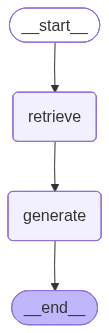

In [24]:
# define the stateGraph:

graph_builder = StateGraph(AgenticRAGState)

# add node
graph_builder.add_node('retrieve', retrieve)
graph_builder.add_node('generate', generate)

# add edge
graph_builder.add_edge(START, 'retrieve')
graph_builder.add_edge('retrieve', 'generate')
graph_builder.add_edge('generate', END)


graph = graph_builder.compile()


graph


In [25]:
test_query = "How will EVS impact oil demand in the next decade?"

result = graph.invoke({"query": test_query, "messages": []})

In [26]:
print("=== GENERATED RESPONSE ===")
print(result["answer"])

=== GENERATED RESPONSE ===
Short answer
- EVs will cut oil demand from passenger and light‑commercial vehicles over the next decade, but the reduction will be partial — not a near‑complete loss of gasoline/diesel demand.

Key points from the report
- Projections: EVs are expected to reach roughly 40–60% of new vehicle sales by 2030; the global EV stock is projected to rise from ~40 million today to about 300–500 million by the early 2030s. (Stock matters more than annual sales for oil displacement.)
- Scale and inertia: the global passenger vehicle fleet is ~1.4 billion (mostly ICE). With ~90 million new vehicle sales per year and typical vehicle lifetimes of 15–20 years (often longer in developing markets), full fleet electrification cannot occur within a single decade — displacement will be gradual as ICE vehicles retire.
- What determines actual oil displacement: three layers must be integrated — the EV sales trajectory, the retirement rate of the existing ICE fleet, and the average